In [1]:
# Load clean data in and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from  sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

CRMLSSold_cleaned = pd.read_csv('data/cleaned_CRMLSSOLD_baseline.csv')
print(CRMLSSold_cleaned.info())
print(display(CRMLSSold_cleaned.head()))

<class 'pandas.DataFrame'>
RangeIndex: 63638 entries, 0 to 63637
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CloseDate              63638 non-null  str    
 1   ClosePrice             63638 non-null  float64
 2   LivingArea             63638 non-null  float64
 3   BedroomsTotal          63638 non-null  int64  
 4   BathroomsTotalInteger  63638 non-null  int64  
 5   YearBuilt              63638 non-null  int64  
 6   GarageSpaces           63638 non-null  float64
 7   LotSizeSquareFeet      63638 non-null  float64
 8   CountyOrParish         63638 non-null  str    
 9   PoolPrivateYN          63638 non-null  str    
 10  ViewYN                 63638 non-null  str    
 11  FireplaceYN            63638 non-null  str    
dtypes: float64(4), int64(3), str(5)
memory usage: 7.9 MB
None


,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,GarageSpaces,LotSizeSquareFeet,CountyOrParish,PoolPrivateYN,ViewYN,FireplaceYN
0,2025-11-30,1250000.0,1027.0,3,2,1961,2.0,5913.0,Orange,False,False,False
1,2025-11-20,2299995.0,1129.0,3,1,1949,2.0,18432.0,Santa Clara,Unknown,False,True
2,2025-11-26,810000.0,1619.0,4,3,1978,2.0,5300.0,San Diego,False,False,True
3,2025-11-17,925000.0,2872.0,5,3,2000,3.0,5272.0,San Diego,False,False,True
4,2025-11-25,1300000.0,1727.0,3,2,1950,3.0,10500.0,San Luis Obispo,False,False,True


None


In [2]:
def make_train_test_split(df, feature_cols, training_months=None):
    """
    Split df into train/test by time.

    test  = the most recent month in the data
    train = the X months immediately before the test month
            if training_months is None, use all available preceding months
    """
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])

    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    test_month  = df['CloseMonth'].max()
    train_start = test_month - training_months if training_months else df['CloseMonth'].min()

    train = df[(df['CloseMonth'] >= train_start) & (df['CloseMonth'] < test_month)].copy()
    test  = df[df['CloseMonth'] == test_month].copy()


    X_train = train[feature_cols]
    y_train = train['ClosePrice']
    X_test  = test[feature_cols]
    y_test  = test['ClosePrice']

    print(f"Test month:  {test_month}")
    print(f"Train range: {train['CloseMonth'].min()} to {train['CloseMonth'].max()}  ({train['CloseMonth'].nunique()} months)")
    print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test, 




Test month:  2026-05
Train range: 2025-11 to 2026-04  (6 months)
X_train: (52916, 11)  |  X_test: (10722, 11)
R^2: 0.7145


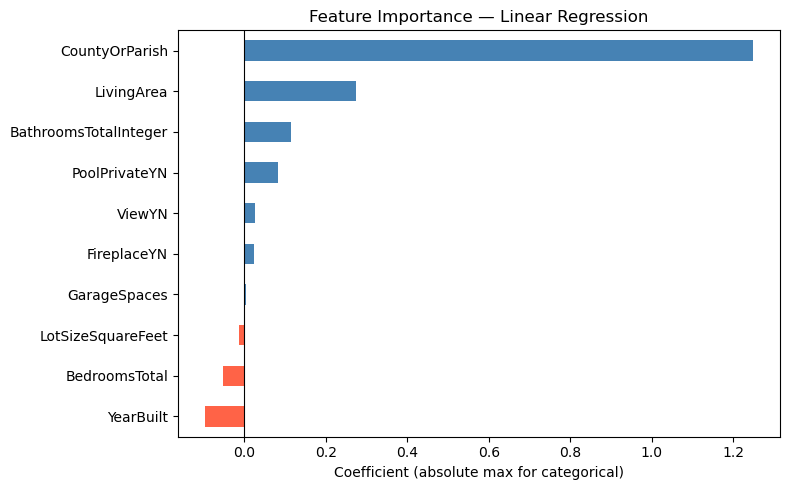

In [3]:
# TODO: Add code for baseline model pipeline here
'''
1. Create a pipeline that includes crating categorical encodings and 
standardizing features then a LinearRegression model.

2. create a train/test split of the data and fit the pipeline to the training data.

3. Evaluate the model on the test data and print out the R^2 score and RMSE.
'''
# all cols except target column
feature_cols = [col for col in CRMLSSold_cleaned.columns if col != 'ClosePrice']
# target column
target_col = 'ClosePrice'
# categorical columns
categorical_cols = ['PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'CountyOrParish']

CRMLSSold_cleaned['ClosePrice'] = np.log(CRMLSSold_cleaned['ClosePrice'])
CRMLSSold_cleaned['LivingArea'] = np.log(CRMLSSold_cleaned['LivingArea'])

preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'GarageSpaces']),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
# Use all available months for training (tunable — change training_months=N to experiment)
X_train, y_train, X_test, y_test = make_train_test_split(
    CRMLSSold_cleaned, feature_cols, training_months=None
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
r2 = pipeline.score(X_test, y_test)
print(f"R^2: {r2:.4f}")

# Feature importance — group OHE columns back to their original feature name (max abs coef)
ohe_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['encode'].get_feature_names_out(categorical_cols).tolist()
num_feature_names = ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'GarageSpaces']
all_feature_names = num_feature_names + ohe_feature_names

coefficients = pipeline.named_steps['model'].coef_
importance = pd.Series(coefficients, index=all_feature_names)

# For categorical features, take the max absolute coefficient across all dummies for that feature
grouped = {}
for name in num_feature_names:
    grouped[name] = importance[name]
for col in categorical_cols:
    dummies = [f for f in ohe_feature_names if f.startswith(col + '_')]
    grouped[col] = importance[dummies].abs().max()

grouped_importance = pd.Series(grouped).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in grouped_importance]
grouped_importance.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (absolute max for categorical)')
ax.set_title('Feature Importance — Linear Regression')
plt.tight_layout()
plt.show()